#### **Problem Statement** :We want to predict whether a person should Play Tennis (Yes) or Not Play Tennis (No) based on weather conditions such as:

##### Outlook
##### Temperature
##### Humidity
##### Wind

#### Import necessary libraries and dataset

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [39]:
df=pd.read_csv(r'playtennis.csv')
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes


#### Understand the dataset

In [40]:
df.shape

(200, 5)

In [41]:
df.dtypes

Outlook        object
Temperature    object
Humidity       object
Wind           object
PlayTennis     object
dtype: object

In [42]:
df.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis'], dtype='object')

In [43]:
df.describe()

,Outlook,Temperature,Humidity,Wind,PlayTennis
count,200,200,191,190,200
unique,3,3,2,2,2
top,Rain,Mild,Normal,Weak,Yes
freq,74,73,99,111,120


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB


#### Exploratory Data Analysis (EDA)

In [45]:
df.isna().sum()

Outlook         0
Temperature     0
Humidity        9
Wind           10
PlayTennis      0
dtype: int64

In [46]:
df.isna().sum()/len(df)*100

Outlook        0.0
Temperature    0.0
Humidity       4.5
Wind           5.0
PlayTennis     0.0
dtype: float64

In [47]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy="most_frequent")
df[["Humidity","Wind"]]= imputer.fit_transform(df[["Humidity","Wind"]])

In [48]:
df.isna().sum()

Outlook        0
Temperature    0
Humidity       0
Wind           0
PlayTennis     0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(154)

#### Encoding

In [50]:
col=df.select_dtypes(include=["object","string"]).columns

for i in col:
    print(f"\n{i}")
    print(df[i].unique())


Outlook
['Sunny' 'Overcast' 'Rain']

Temperature
['Hot' 'Mild' 'Cool']

Humidity
['High' 'Normal']

Wind
['Weak' 'Strong']

PlayTennis
['No' 'Yes']


In [51]:
cols=['Outlook','Temperature','Humidity','Wind']
cols

['Outlook', 'Temperature', 'Humidity', 'Wind']

In [52]:
df=pd.get_dummies(data=df, columns=cols,dtype=int)

In [53]:
df['PlayTennis']=df['PlayTennis'].map({"No":0, "Yes":1})

In [54]:
df.head()

,PlayTennis,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,0,0,0,1,0,1,0,1,0,0,1
1,0,1,0,0,0,0,1,0,1,1,0
2,1,1,0,0,1,0,0,0,1,0,1
3,0,0,1,0,0,0,1,1,0,1,0
4,1,0,1,0,0,1,0,0,1,0,1


#### Find Correlation features and target columns

Humidity_High      -0.434135
Humidity_Normal     0.434135
Outlook_Overcast    0.431854
Outlook_Rain       -0.304408
Wind_Strong        -0.196253
Wind_Weak           0.196253
Temperature_Mild    0.152638
Temperature_Cool   -0.143256
Outlook_Sunny      -0.103418
Temperature_Hot    -0.013301
Name: PlayTennis, dtype: float64


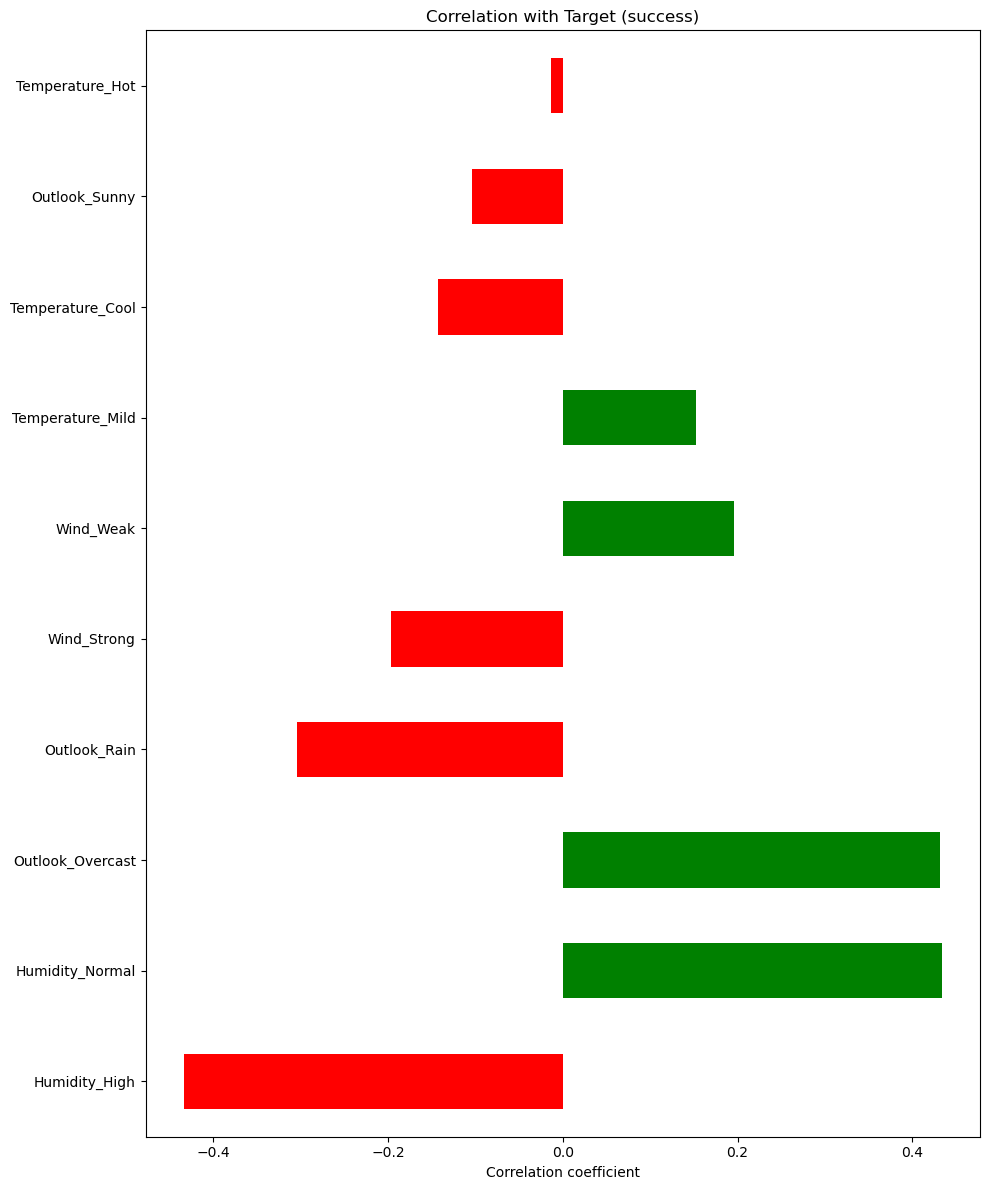

In [55]:
numeric_df = df.select_dtypes(include=[int,float])
target_corr = numeric_df.corr()['PlayTennis'].drop('PlayTennis').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(10,12))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (success)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

#### Define X and y

In [56]:
X=df.drop(columns=['PlayTennis'])
y=df['PlayTennis']

#### Train Test Split

In [57]:
Xtrain,Xtest,ytrain,ytest= train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
dt= DecisionTreeClassifier(random_state=42)

ada_model=AdaBoostClassifier(estimator=dt,random_state=42)

ada_model.fit(Xtrain,ytrain)

AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                   random_state=42)

In [59]:
ypred=ada_model.predict(Xtest)

print(f"Training Accuracy: {ada_model.score(Xtrain,ytrain)}")
print(f"Testing Accuracy: {ada_model.score(Xtest,ytest)}")

print(classification_report(ytest,ypred))

Training Accuracy: 0.9125
Testing Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.96      0.96      0.96        24

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



#### Hyperparameter Tuning

In [62]:
param_grid = {"n_estimators": [50, 100, 150, 200],
              "learning_rate": [0.01, 0.1, 0.5, 1.0],
              "estimator__max_depth": [1, 2, 3]
            }

In [63]:
ada = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Train
ada.fit(Xtrain, ytrain)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='accuracy', verbose=1)

In [65]:
print("Best Parameters:")
print(ada.best_params_)

print("Best CV Score:")
print(ada.best_score_)

Best Parameters:
{'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 50}
Best CV Score:
0.9125


In [66]:
Final_model= AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    learning_rate=0.1,
    n_estimators=50,
    random_state=42
)

In [71]:
Final_model.fit(Xtrain,ytrain)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=42),
                   learning_rate=0.1, random_state=42)

In [73]:
ypred=Final_model.predict(Xtest)

print(f"Training_accuracy: {Final_model.score(Xtrain,ytrain)}")
print(f"Testing_accuracy: {Final_model.score(Xtest,ytest)}")
print(classification_report(ytest,ypred))

Training_accuracy: 0.9125
Testing_accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        24

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



#### conclusion:

In this project, an AdaBoost classification model was developed to predict the target variable using a Decision Tree as the base estimator. The dataset was cleaned, explored, and prepared through appropriate preprocessing before model training.

A baseline AdaBoost model was initially trained and achieved **91.25% training accuracy and 95% testing accuracy**. Hyperparameter tuning was then performed using **GridSearchCV with 5-fold cross-validation**. The optimal parameters were:

* **n_estimators:** 50
* **learning_rate:** 0.1
* **Decision Tree max_depth:** 3
* **Best cross-validation accuracy:** 91.25%

The final tuned AdaBoost model achieved **91.25% training accuracy and 97.5% testing accuracy**.

The classification report showed:

* **Class 0:** Precision = 1.00, Recall = 0.94, F1-score = 0.97
* **Class 1:** Precision = 0.96, Recall = 1.00, F1-score = 0.98
* **Overall Accuracy:** 97.5%
* **Macro F1-score:** 0.97

The model demonstrated strong classification performance on the available test set, particularly in identifying Class 1 observations with **100% recall**. Hyperparameter tuning improved the observed test accuracy from **95% to 97.5%**.

